**Ứng dụng mô hình RF và XGBoost vào tập dữ liệu**

1.Load dữ liệu đã được preprocess

In [ ]:
# === Upload Train / Valid / Test files ===
from google.colab import files
import pandas as pd
import io

print("Upload TRAIN file...")
uploaded = files.upload()
train_filename = list(uploaded.keys())[0]
train_df = pd.read_csv(io.BytesIO(uploaded[train_filename]))

print("Upload VALID file...")
uploaded = files.upload()
valid_filename = list(uploaded.keys())[0]
valid_df = pd.read_csv(io.BytesIO(uploaded[valid_filename]))

print("Upload TEST file...")
uploaded = files.upload()
test_filename = list(uploaded.keys())[0]
test_df = pd.read_csv(io.BytesIO(uploaded[test_filename]))

print("Files loaded:")
print(" Train:", train_filename, train_df.shape)
print(" Valid:", valid_filename, valid_df.shape)
print(" Test :", test_filename, test_df.shape)


Upload TRAIN file...


Saving train_data (3).csv to train_data (3).csv
Upload VALID file...


Saving valid_data (3).csv to valid_data (3).csv
Upload TEST file...


Saving test_data (3).csv to test_data (3).csv
Files loaded:
 Train: train_data (3).csv (4906, 25)
 Valid: valid_data (3).csv (1636, 25)
 Test : test_data (3).csv (3258, 25)


2. Gán biến cố địng cho từng tập dữ liệu

In [ ]:
# === Split features/labels ===
label_col = "Sales"  # Sửa nếu tên cột khác

# Train
X_train = train_df.drop(columns=[label_col]).values
y_train = train_df[label_col].values

# Valid
X_valid = valid_df.drop(columns=[label_col]).values
y_valid = valid_df[label_col].values

# Test
X_test  = test_df.drop(columns=[label_col]).values
y_test  = test_df[label_col].values

print("Shapes:")
print(" X_train:", X_train.shape, " y_train:", y_train.shape)
print(" X_valid:", X_valid.shape, " y_valid:", y_valid.shape)
print(" X_test :", X_test.shape,  " y_test :", y_test.shape)


Shapes:
 X_train: (4906, 24)  y_train: (4906,)
 X_valid: (1636, 24)  y_valid: (1636,)
 X_test : (3258, 24)  y_test : (3258,)


3. Tìm best wide param cho RF

In [ ]:
import time, math, numpy as np, pprint
from sklearn.model_selection import ParameterSampler
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pp = pprint.PrettyPrinter(indent=2)


def make_metric_fn(name_or_callable):
    if callable(name_or_callable):
        return name_or_callable
    name = str(name_or_callable).lower()
    if name == "r2":
        return lambda y_true, y_pred: float(r2_score(np.asarray(y_true).ravel(), np.asarray(y_pred).ravel()))
    if name == "mae":
        return lambda y_true, y_pred: -float(mean_absolute_error(np.asarray(y_true).ravel(), np.asarray(y_pred).ravel()))
    if name == "rmse":
        return lambda y_true, y_pred: -float(math.sqrt(mean_squared_error(np.asarray(y_true).ravel(), np.asarray(y_pred).ravel())))
    raise ValueError("Unknown metric name and not callable: "+str(name_or_callable))

def eval_reg(y_true, y_pred):
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    return {
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "RMSE": float(math.sqrt(mean_squared_error(y_true, y_pred))),
        "R2": float(r2_score(y_true, y_pred))
    }


def random_search_custom_metric(ModelClass, param_space, n_iter, X_tr, y_tr, X_val, y_val,
                                metric="mae", xgb_early_stop=False, verbose_every=10):
    metric_fn = make_metric_fn(metric)
    sampler = list(ParameterSampler(param_space, n_iter=n_iter, random_state=42))
    best_score = -1e12
    best_param = None
    best_model = None
    t0 = time.time()

    for i, p in enumerate(sampler, 1):
        # fit
        if ModelClass is XGBRegressor:
            p_local = dict(p)
            model = ModelClass(tree_method="hist", random_state=42, n_jobs=-1, eval_metric="rmse", **p_local)
            if xgb_early_stop:
                try:
                    model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], early_stopping_rounds=50, verbose=False)
                except Exception:
                    model.fit(X_tr, y_tr, verbose=False)
            else:
                model.fit(X_tr, y_tr, verbose=False)
        else:
            model = ModelClass(random_state=42, n_jobs=-1, **p)
            model.fit(X_tr, y_tr)

        pred = model.predict(X_val)
        score = metric_fn(y_val, pred)

        if score > best_score:
            best_score = score
            best_param = p
            best_model = model

        if verbose_every and (i % verbose_every == 0 or i == len(sampler)):
            hr = eval_reg(y_val, pred)
            print(f" tried {i}/{len(sampler)} | sample metric(wrapper) {score:.5f} | human: R2={hr['R2']:.4f}, MAE={hr['MAE']:.4f}")

    duration = time.time() - t0
    print(f"random_search finished in {duration:.1f}s | best (wrapped metric) score: {best_score:.5f}")
    return best_param, best_model, best_score

chosen_metric = "mae"

# ===== RF WIDE SEARCH space =====
rf_space_wide = {
    "n_estimators":[300,500,800,1200,1600],
    "max_depth":[8,10,12,15,20,None],
    "min_samples_split":[2,4,6],
    "min_samples_leaf":[1,2,3,4],
    "max_features":["sqrt","log2",0.6,0.8],
    "bootstrap":[True, False]
}

print("=== RF WIDE SEARCH (metric = MAE) ===")
rf_best_wide_param, rf_model_wide, rf_wide_score = random_search_custom_metric(
    RandomForestRegressor, rf_space_wide, n_iter=40,
    X_tr=X_train, y_tr=y_train, X_val=X_valid, y_val=y_valid,
    metric=chosen_metric, xgb_early_stop=False, verbose_every=10
)

print("\nRF best WIDE param:")
pp.pprint(rf_best_wide_param)
print("RF WIDE human metrics (on VALID):", eval_reg(y_valid, rf_model_wide.predict(X_valid)))


=== RF WIDE SEARCH (metric = MAE) ===
 tried 10/40 | sample metric(wrapper) -167.80574 | human: R2=0.4602, MAE=167.8057
 tried 20/40 | sample metric(wrapper) -184.17597 | human: R2=0.3870, MAE=184.1760
 tried 30/40 | sample metric(wrapper) -166.43274 | human: R2=0.4356, MAE=166.4327
 tried 40/40 | sample metric(wrapper) -173.03749 | human: R2=0.4088, MAE=173.0375
random_search finished in 319.1s | best (wrapped metric) score: -163.79581

RF best WIDE param:
{ 'bootstrap': False,
  'max_depth': 8,
  'max_features': 0.6,
  'min_samples_leaf': 3,
  'min_samples_split': 6,
  'n_estimators': 500}
RF WIDE human metrics (on VALID): {'MAE': 163.79581388316564, 'RMSE': 403.9451921621809, 'R2': 0.48428497559102457}


4.Tìm narrow param cho RF dựa trên wide param

In [ ]:

import numpy as np, pprint
pp = pprint.PrettyPrinter(indent=2)
# ---- Config
RUN_NARROW2 = False
RUN_REFIT = False
N_ITER_NARROW = 200


try:
    rf_best_wide_param
except NameError:
    raise RuntimeError("rf_best_wide_param không tồn tại. Chạy Cell 1 (RF WIDE) trước.")

# ---- dedupe helper
def dedupe_keep_order(lst):
    seen = set()
    out = []
    for x in lst:
        key = (type(x), x)
        if key not in seen:
            seen.add(key)
            out.append(x)
    return out

# ---- smart narrow builder (improved max_features)
def rf_narrow_from_wide(w):
    def around_int(v):
        v = int(v) if v is not None else 300
        return sorted(list(set([max(1,v-100), max(1,v-50), v, v+50, v+100])))
    space = {}
    space['n_estimators'] = around_int(w.get('n_estimators', 300))
    md = w.get('max_depth', None)
    if md is None:
        space['max_depth'] = [None, 8, 10, 12, 15]
    else:
        md = int(md)
        space['max_depth'] = sorted(list(set([max(1,md-3), md-1, md, md+1, md+3])))
    space['min_samples_split'] = sorted(list(set([max(2,w.get('min_samples_split',2)-1), w.get('min_samples_split',2), w.get('min_samples_split',2)+1])))
    space['min_samples_leaf']  = sorted(list(set([max(1,w.get('min_samples_leaf',1)-1), w.get('min_samples_leaf',1), w.get('min_samples_leaf',1)+1])))
    mf = w.get('max_features', 'sqrt')
    mf_candidates = []
    if isinstance(mf, str):
        if mf == "sqrt":
            mf_candidates = ["sqrt", "log2", 0.6, 0.8]
        elif mf == "log2":
            mf_candidates = ["log2", "sqrt", 0.6, 0.8]
        else:
            mf_candidates = [mf, "sqrt", "log2", 0.8]
    else:
        try:
            mf_val = float(mf)
            mf_candidates = [round(x,3) for x in (mf_val, 0.6, 0.7, 0.8)]
            mf_candidates += ["sqrt", "log2"]
        except Exception:
            mf_candidates = ["sqrt", "log2", 0.6, 0.8]
    space['max_features'] = dedupe_keep_order(mf_candidates)
    space['bootstrap'] = [w.get('bootstrap', True)]
    return space

# ---- Build narrow & display
rf_space_narrow = rf_narrow_from_wide(rf_best_wide_param)
print("RF narrow search space (built from wide-best):")
pp.pprint(rf_space_narrow)

# ---- Run narrow search (MAE)
print("\n=== RF NARROW SEARCH (metric = MAE) ===")
rf_best_narrow_param, rf_model_narrow, rf_narrow_score = random_search_custom_metric(
    RandomForestRegressor, rf_space_narrow, n_iter=N_ITER_NARROW,
    X_tr=X_train, y_tr=y_train, X_val=X_valid, y_val=y_valid,
    metric=chosen_metric, xgb_early_stop=False, verbose_every=10
)

print("\nRF best NARROW param:")
pp.pprint(rf_best_narrow_param)
print("RF NARROW human metrics (on VALID):", eval_reg(y_valid, rf_model_narrow.predict(X_valid)))

# ---- Optional narrow2
if RUN_NARROW2:
    rf_space_narrow2 = rf_narrow_from_wide(rf_best_narrow_param)
    print("\nRF narrow2 space:")
    pp.pprint(rf_space_narrow2)
    rf_best_narrow2_param, rf_model_narrow2, rf_narrow2_score = random_search_custom_metric(
        RandomForestRegressor, rf_space_narrow2, n_iter=100,
        X_tr=X_train, y_tr=y_train, X_val=X_valid, y_val=y_valid,
        metric=chosen_metric, xgb_early_stop=False, verbose_every=10
    )
    print("RF best NARROW2 param:")
    pp.pprint(rf_best_narrow2_param)
    print("RF NARROW2 human metrics:", eval_reg(y_valid, rf_model_narrow2.predict(X_valid)))
    rf_best_narrow_param = rf_best_narrow2_param
    rf_model_narrow = rf_model_narrow2
    rf_narrow_score = rf_narrow2_score

# ---- Optional refit final on Train+Valid
rf_final = None
if RUN_REFIT:
    X_comb = np.concatenate([X_train, X_valid], axis=0)
    y_comb = np.concatenate([y_train, y_valid], axis=0)
    rf_final = RandomForestRegressor(random_state=42, n_jobs=-1, **rf_best_narrow_param)
    rf_final.fit(X_comb, y_comb)
    print("Refit done. Sanity on VALID:", eval_reg(y_valid, rf_final.predict(X_valid)))



RF narrow search space (built from wide-best):
{ 'bootstrap': [False],
  'max_depth': [5, 7, 8, 9, 11],
  'max_features': [0.6, 0.7, 0.8, 'sqrt', 'log2'],
  'min_samples_leaf': [2, 3, 4],
  'min_samples_split': [5, 6, 7],
  'n_estimators': [400, 450, 500, 550, 600]}

=== RF NARROW SEARCH (metric = MAE) ===
 tried 10/200 | sample metric(wrapper) -166.57896 | human: R2=0.4583, MAE=166.5790
 tried 20/200 | sample metric(wrapper) -162.40406 | human: R2=0.4644, MAE=162.4041
 tried 30/200 | sample metric(wrapper) -163.67803 | human: R2=0.4657, MAE=163.6780
 tried 40/200 | sample metric(wrapper) -171.05057 | human: R2=0.4775, MAE=171.0506
 tried 50/200 | sample metric(wrapper) -164.79496 | human: R2=0.4722, MAE=164.7950
 tried 60/200 | sample metric(wrapper) -186.88489 | human: R2=0.4105, MAE=186.8849
 tried 70/200 | sample metric(wrapper) -186.88489 | human: R2=0.4105, MAE=186.8849
 tried 80/200 | sample metric(wrapper) -169.36826 | human: R2=0.4767, MAE=169.3683
 tried 90/200 | sample metri

5. Tìm narrow param cho XGBoost

In [ ]:

import numpy as np, pprint
pp = pprint.PrettyPrinter(indent=2)

xgb_space_wide = {
    "n_estimators":       [800, 1200, 1600, 2000, 3000],
    "learning_rate":      [0.01, 0.02, 0.03, 0.05],
    "max_depth":          [4, 5, 6, 8, 10],
    "min_child_weight":   [1, 2, 3, 5],
    "subsample":          [0.6, 0.7, 0.8, 0.9, 1.0],
    "colsample_bytree":   [0.6, 0.7, 0.8, 0.9, 1.0],
    "reg_alpha":          [0, 0.1, 0.3, 0.5],
    "reg_lambda":         [1, 2, 4, 6]
}

pp.pprint(xgb_space_wide)

N_ITER_WIDE = 50

print(f"\n=== XGB WIDE SEARCH (metric = MAE) ===")
xgb_best_wide_param, xgb_model_wide, xgb_wide_score = random_search_custom_metric(
    XGBRegressor, xgb_space_wide, n_iter=N_ITER_WIDE,
    X_tr=X_train, y_tr=y_train, X_val=X_valid, y_val=y_valid,
    metric=chosen_metric, xgb_early_stop=True, verbose_every=10
)

print("\nXGB best WIDE param:")
pp.pprint(xgb_best_wide_param)
print("\nXGB WIDE human metrics (on VALID):", eval_reg(y_valid, xgb_model_wide.predict(X_valid)))


{ 'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
  'learning_rate': [0.01, 0.02, 0.03, 0.05],
  'max_depth': [4, 5, 6, 8, 10],
  'min_child_weight': [1, 2, 3, 5],
  'n_estimators': [800, 1200, 1600, 2000, 3000],
  'reg_alpha': [0, 0.1, 0.3, 0.5],
  'reg_lambda': [1, 2, 4, 6],
  'subsample': [0.6, 0.7, 0.8, 0.9, 1.0]}

=== XGB WIDE SEARCH (metric = MAE) ===
 tried 10/50 | sample metric(wrapper) -192.25170 | human: R2=0.3728, MAE=192.2517
 tried 20/50 | sample metric(wrapper) -171.68943 | human: R2=0.4644, MAE=171.6894
 tried 30/50 | sample metric(wrapper) -203.11425 | human: R2=0.3575, MAE=203.1143
 tried 40/50 | sample metric(wrapper) -179.41158 | human: R2=0.3903, MAE=179.4116
 tried 50/50 | sample metric(wrapper) -190.03666 | human: R2=0.2534, MAE=190.0367
random_search finished in 109.6s | best (wrapped metric) score: -165.30001

XGB best WIDE param:
{ 'colsample_bytree': 0.8,
  'learning_rate': 0.01,
  'max_depth': 5,
  'min_child_weight': 5,
  'n_estimators': 800,
  'reg_alpha': 0

6. Tìm narrow param dựa trên wide param

In [ ]:

import numpy as np, pprint
pp = pprint.PrettyPrinter(indent=2)

# ---- Config (chỉnh nếu muốn) ----
N_ITER_NARROW = 200
RUN_NARROW2 = False
N_ITER_NARROW2 = 100
RUN_REFIT = False
VERBOSE_EVERY = 10


try:
    xgb_best_wide_param
except NameError:
    raise RuntimeError("xgb_best_wide_param không tồn tại. Chạy XGB WIDE (Cell 3) trước.")


def xgb_narrow_from_wide(w):
    def near_int(v, deltas=(-200, -100, 0, 100, 200)):
        v = int(v)
        return sorted(list(set([max(10, v + d) for d in deltas])))
    def near_float(v, span=0.02):
        v = float(v)
        low = max(0.001, v - span)
        high = min(1.0, v + span)
        return sorted(list(set([round(low,4),
                                round(max(0.001, v-span/2),4),
                                round(v,4),
                                round(min(1.0, v+span/2),4),
                                round(high,4)])))
    space = {}
    # n_estimators
    space['n_estimators'] = near_int(w.get('n_estimators', 1000))
    # max_depth
    md = int(w.get('max_depth', 6))
    space['max_depth'] = sorted(list(set([max(1, md-1), md, md+1])))
    # learning_rate
    space['learning_rate'] = near_float(w.get('learning_rate', 0.02))
    # min_child_weight
    mcw = int(w.get('min_child_weight', 1))
    space['min_child_weight'] = sorted(list(set([max(1, mcw-1), mcw, mcw+1])))
    # subsample / colsample_bytree
    ss = float(w.get('subsample', 0.8))
    cs = float(w.get('colsample_bytree', 0.8))
    space['subsample'] = sorted(list(set([round(x,3) for x in (ss, 0.6, 0.7, 0.8, 0.9)])))
    space['colsample_bytree'] = sorted(list(set([round(x,3) for x in (cs, 0.6, 0.7, 0.8, 0.9)])))
    # reg_alpha / reg_lambda
    space['reg_alpha'] = sorted(list(set([w.get('reg_alpha', 0), 0.0, 0.1, 0.2])))
    space['reg_lambda'] = sorted(list(set([w.get('reg_lambda', 1), 1, 3, 5])))
    return space

# ---- Build narrow space and display ----
xgb_space_narrow = xgb_narrow_from_wide(xgb_best_wide_param)
print("XGB narrow search space (from wide-best):")
pp.pprint(xgb_space_narrow)

# ---- Run narrow search (with early stopping enabled) ----
print("\n=== XGB NARROW SEARCH (metric = {}) ===".format(chosen_metric if not callable(chosen_metric) else "custom_fn"))
xgb_best_narrow_param, xgb_model_narrow, xgb_narrow_score = random_search_custom_metric(
    XGBRegressor, xgb_space_narrow, n_iter=N_ITER_NARROW,
    X_tr=X_train, y_tr=y_train, X_val=X_valid, y_val=y_valid,
    metric=chosen_metric, xgb_early_stop=True, verbose_every=VERBOSE_EVERY
)

print("\nXGB best NARROW param:")
pp.pprint(xgb_best_narrow_param)
print("XGB NARROW human metrics (on VALID):", eval_reg(y_valid, xgb_model_narrow.predict(X_valid)))

# ---- Optional: NARROW2 ----
if RUN_NARROW2:
    print("\n--- Running XGB NARROW2 around xgb_best_narrow_param ---")
    xgb_space_narrow2 = xgb_narrow_from_wide(xgb_best_narrow_param)
    pp.pprint(xgb_space_narrow2)
    xgb_best_narrow2_param, xgb_model_narrow2, xgb_narrow2_score = random_search_custom_metric(
        XGBRegressor, xgb_space_narrow2, n_iter=N_ITER_NARROW2,
        X_tr=X_train, y_tr=y_train, X_val=X_valid, y_val=y_valid,
        metric=chosen_metric, xgb_early_stop=True, verbose_every=VERBOSE_EVERY
    )
    print("\nXGB best NARROW2 param:")
    pp.pprint(xgb_best_narrow2_param)
    print("XGB NARROW2 human metrics (on VALID):", eval_reg(y_valid, xgb_model_narrow2.predict(X_valid)))
    # update bests
    xgb_best_narrow_param = xgb_best_narrow2_param
    xgb_model_narrow = xgb_model_narrow2
    xgb_narrow_score = xgb_narrow2_score

# ---- Optional: refit final on Train+Valid (no test) ----
xgb_final = None
if RUN_REFIT:
    print("\n--- Refitting XGB final on Train+Valid using xgb_best_narrow_param ---")
    X_comb = np.concatenate([X_train, X_valid], axis=0)
    y_comb = np.concatenate([y_train, y_valid], axis=0)
    xgb_final = XGBRegressor(tree_method="hist", random_state=42, n_jobs=-1, eval_metric="rmse", **xgb_best_narrow_param)
    xgb_final.fit(X_comb, y_comb, verbose=False)
    print("Refit done. (model stored in variable xgb_final)")
    print("Sanity (VALID) metrics of xgb_final:", eval_reg(y_valid, xgb_final.predict(X_valid)))

# ---- Summary ----
print("\n=== XGB NARROW COMPLETE ===")
print("xgb_best_wide_param (from Cell3):")
pp.pprint(xgb_best_wide_param)
print("\nxgb_best_narrow_param (this cell):")
pp.pprint(xgb_best_narrow_param)
print("\nxgb_narrow_score (reported metric):", xgb_narrow_score)
if xgb_final is not None:
    print("xgb_final fitted on Train+Valid available as xgb_final.")


XGB narrow search space (from wide-best):
{ 'colsample_bytree': [0.6, 0.7, 0.8, 0.9],
  'learning_rate': [0.001, 0.01, 0.02, 0.03],
  'max_depth': [4, 5, 6],
  'min_child_weight': [4, 5, 6],
  'n_estimators': [600, 700, 800, 900, 1000],
  'reg_alpha': [0, 0.1, 0.2],
  'reg_lambda': [1, 3, 5],
  'subsample': [0.6, 0.7, 0.8, 0.9]}

=== XGB NARROW SEARCH (metric = mae) ===
 tried 10/200 | sample metric(wrapper) -172.12796 | human: R2=0.4511, MAE=172.1280
 tried 20/200 | sample metric(wrapper) -170.98808 | human: R2=0.4754, MAE=170.9881
 tried 30/200 | sample metric(wrapper) -176.28867 | human: R2=0.4440, MAE=176.2887
 tried 40/200 | sample metric(wrapper) -172.33959 | human: R2=0.4613, MAE=172.3396
 tried 50/200 | sample metric(wrapper) -169.09897 | human: R2=0.4847, MAE=169.0990
 tried 60/200 | sample metric(wrapper) -166.60881 | human: R2=0.4877, MAE=166.6088
 tried 70/200 | sample metric(wrapper) -172.36950 | human: R2=0.4658, MAE=172.3695
 tried 80/200 | sample metric(wrapper) -219.81

7.  Refit RF & XGB (best narrow) on Train+Valid, evaluate on TEST

In [ ]:
# ===== CELL: Refit RF & XGB (best narrow) on Train+Valid, evaluate on TEST, save models =====
import numpy as np, pprint, joblib, pandas as pd
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

pp = pprint.PrettyPrinter(indent=2)

# ---- Safety checks
missing = []
for name in ["rf_best_narrow_param", "xgb_best_narrow_param", "X_train", "y_train", "X_valid", "y_valid", "X_test", "y_test"]:
    if name not in globals():
        missing.append(name)
if missing:
    raise RuntimeError("Thiếu biến cần thiết trong workspace: " + ", ".join(missing) +
                       ". Chạy các cell trước đó để tạo các biến này.")

# ---- Combine train + valid
X_comb = np.concatenate([X_train, X_valid], axis=0)
y_comb = np.concatenate([y_train, y_valid], axis=0)

print("Refitting RandomForest with rf_best_narrow_param:")
pp.pprint(rf_best_narrow_param)
rf_final = RandomForestRegressor(random_state=42, n_jobs=-1, **rf_best_narrow_param)
rf_final.fit(X_comb, y_comb)

print("\nRefitting XGB with xgb_best_narrow_param:")
pp.pprint(xgb_best_narrow_param)
xgb_final = XGBRegressor(tree_method="hist", random_state=42, n_jobs=-1, eval_metric="rmse", **xgb_best_narrow_param)
# Final fit (no early stopping)
xgb_final.fit(X_comb, y_comb, verbose=False)

# ---- Evaluate on TEST
rf_test_pred = rf_final.predict(X_test)
xgb_test_pred = xgb_final.predict(X_test)

rf_test_metrics  = eval_reg(y_test, rf_test_pred)
xgb_test_metrics = eval_reg(y_test, xgb_test_pred)

print("\n=== TEST METRICS ===")
print("RandomForest (final) on TEST:", rf_test_metrics)
print("XGBoost    (final) on TEST:", xgb_test_metrics)

# ---- Summary table
df = pd.DataFrame([
    {"model":"RandomForest", "MAE":rf_test_metrics["MAE"], "RMSE":rf_test_metrics["RMSE"], "R2":rf_test_metrics["R2"]},
    {"model":"XGBoost",      "MAE":xgb_test_metrics["MAE"], "RMSE":xgb_test_metrics["RMSE"], "R2":xgb_test_metrics["R2"]},
]).set_index("model")
print("\nComparison (TEST):")
display(df)  # Jupyter/Colab friendly
print(df.to_string())

# ---- Save models
joblib.dump(rf_final, "rf_final_best_narrow.joblib")
joblib.dump(xgb_final, "xgb_final_best_narrow.joblib")
print("\nSaved models: rf_final_best_narrow.joblib, xgb_final_best_narrow.joblib")


Refitting RandomForest with rf_best_narrow_param:
{ 'bootstrap': False,
  'max_depth': 7,
  'max_features': 0.8,
  'min_samples_leaf': 3,
  'min_samples_split': 5,
  'n_estimators': 550}

Refitting XGB with xgb_best_narrow_param:
{ 'colsample_bytree': 0.8,
  'learning_rate': 0.01,
  'max_depth': 6,
  'min_child_weight': 4,
  'n_estimators': 700,
  'reg_alpha': 0,
  'reg_lambda': 5,
  'subsample': 0.9}

=== TEST METRICS ===
RandomForest (final) on TEST: {'MAE': 177.75271843091627, 'RMSE': 512.1836032802216, 'R2': 0.23956689356176342}
XGBoost    (final) on TEST: {'MAE': 172.23749110733587, 'RMSE': 457.9647085204682, 'R2': 0.39204183194883224}

Comparison (TEST):


,MAE,RMSE,R2
model,,,
RandomForest,177.752718,512.183603,0.239567
XGBoost,172.237491,457.964709,0.392042


                     MAE        RMSE        R2
model                                         
RandomForest  177.752718  512.183603  0.239567
XGBoost       172.237491  457.964709  0.392042

Saved models: rf_final_best_narrow.joblib, xgb_final_best_narrow.joblib


In [ ]:
# Tạo danh sách tên cột theo đúng thứ tự đã feed vào model
feature_names = train_df.drop(columns=[label_col]).columns.tolist()

print("Số lượng features:", len(feature_names))
print("Danh sách feature_names:")
print(feature_names)


Số lượng features: 24
Danh sách feature_names:
['Order_Sales_Sum', 'customer_avg_sales', 'Ship Mode_First Class', 'Ship Mode_Same Day', 'Ship Mode_Second Class', 'Ship Mode_Standard Class', 'Category_Furniture', 'Category_Office Supplies', 'Category_Technology', 'Segment_Consumer', 'Segment_Corporate', 'Segment_Home Office', 'Region_Central', 'Region_East', 'Region_South', 'Region_West', 'Season_Fall', 'Season_Spring', 'Season_Summer', 'Season_Winter', 'City_freq', 'State_freq', 'Sub-Category_freq', 'Product Name_freq']


8.FEATURE IMPORTANCE (TOP 5) FOR RF & XGB

In [ ]:
# ===== CELL: FEATURE IMPORTANCE (TOP 5) FOR RF & XGB =====
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rf_imp = rf_final.feature_importances_
xgb_imp = xgb_final.feature_importances_

rf_df = pd.DataFrame({"feature": feature_names, "importance": rf_imp}).sort_values("importance", ascending=False)
xgb_df = pd.DataFrame({"feature": feature_names, "importance": xgb_imp}).sort_values("importance", ascending=False)

print("\n=== TOP 10 RF ===")
print(rf_df.head(10))

print("\n=== TOP 10 XGB ===")
print(xgb_df.head(10))



=== TOP 10 RF ===
                     feature  importance
22         Sub-Category_freq    0.284892
0            Order_Sales_Sum    0.229470
21                State_freq    0.149733
1         customer_avg_sales    0.116450
20                 City_freq    0.051889
7   Category_Office Supplies    0.044296
9           Segment_Consumer    0.036294
23         Product Name_freq    0.030448
4     Ship Mode_Second Class    0.011495
6         Category_Furniture    0.008550

=== TOP 10 XGB ===
                     feature  importance
0            Order_Sales_Sum    0.105219
22         Sub-Category_freq    0.095924
7   Category_Office Supplies    0.086597
1         customer_avg_sales    0.078772
14              Region_South    0.071445
6         Category_Furniture    0.060629
11       Segment_Home Office    0.053171
18             Season_Summer    0.047698
21                State_freq    0.044307
9           Segment_Consumer    0.041938


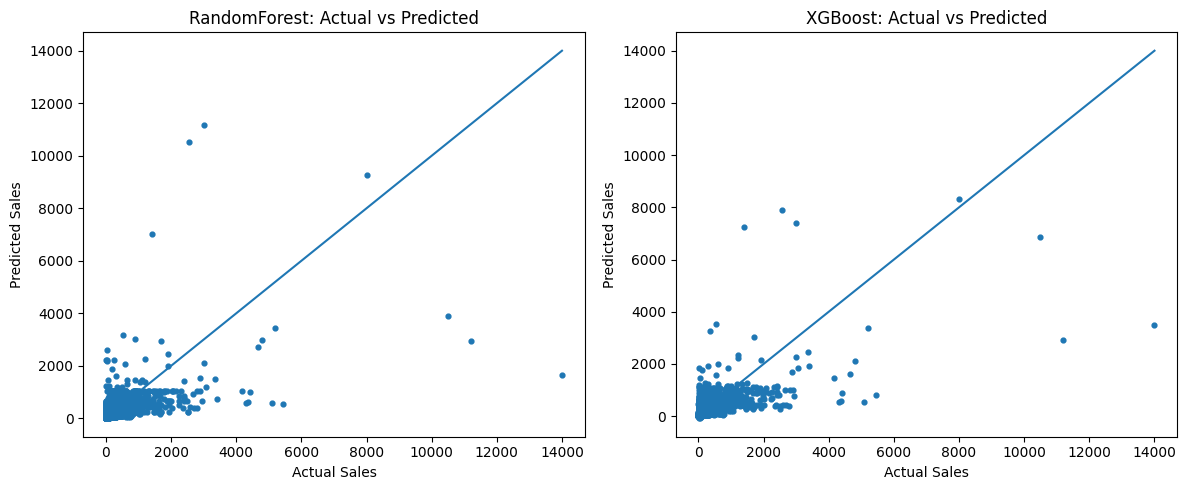

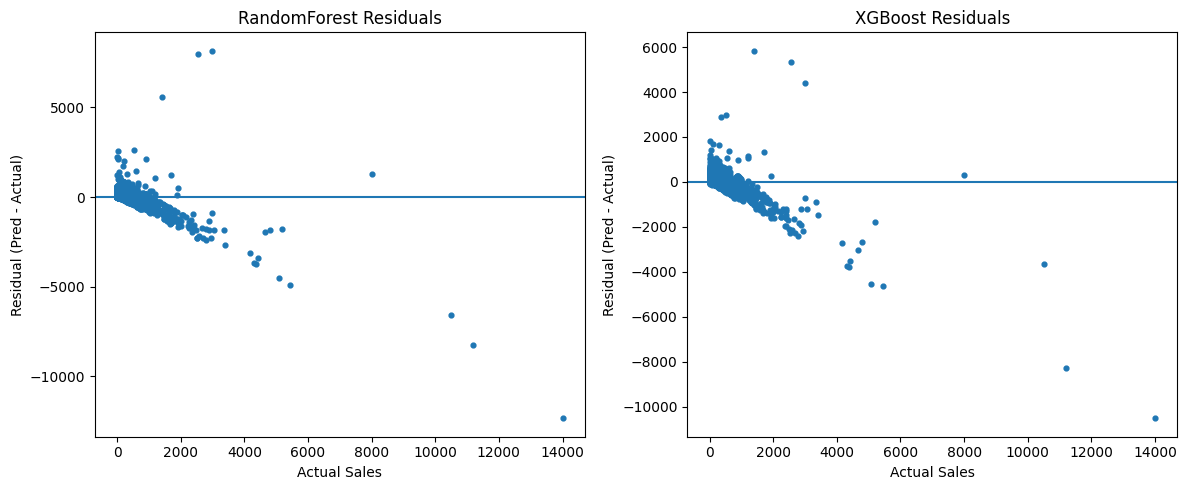

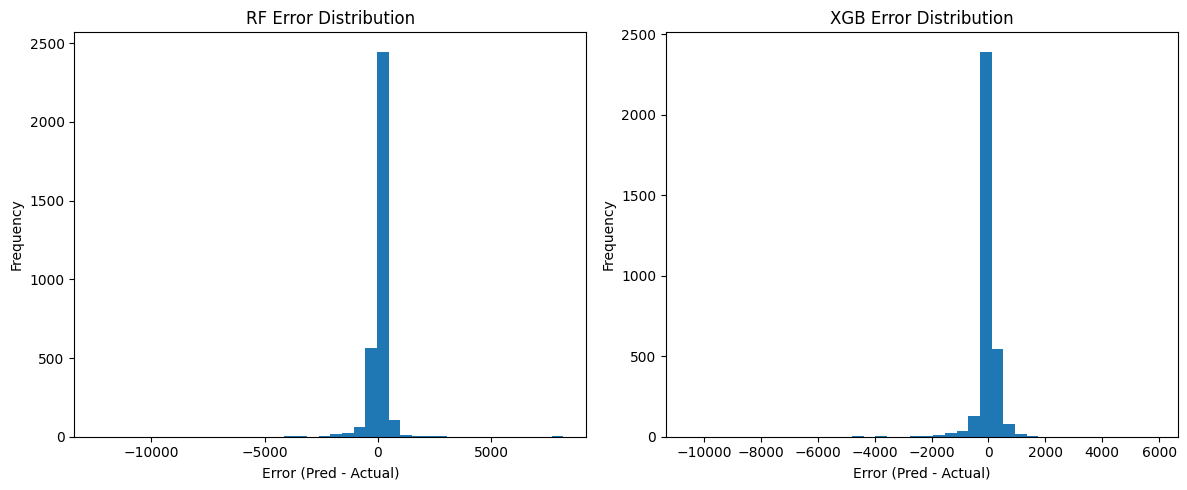

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ----- Dữ liệu -----
y_true = y_test
rf_pred = rf_final.predict(X_test)
xgb_pred = xgb_final.predict(X_test)

# ======= 1) Scatter plot: Actual vs Predicted =======
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.scatter(y_true, rf_pred, s=12)
plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()])
plt.title("RandomForest: Actual vs Predicted")
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")

plt.subplot(1,2,2)
plt.scatter(y_true, xgb_pred, s=12)
plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()])
plt.title("XGBoost: Actual vs Predicted")
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")

plt.tight_layout()
plt.show()


# ======= 2) Residual Plot (Error = Pred - Actual) =======
rf_residual = rf_pred - y_true
xgb_residual = xgb_pred - y_true

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.scatter(y_true, rf_residual, s=12)
plt.axhline(0)
plt.title("RandomForest Residuals")
plt.xlabel("Actual Sales")
plt.ylabel("Residual (Pred - Actual)")

plt.subplot(1,2,2)
plt.scatter(y_true, xgb_residual, s=12)
plt.axhline(0)
plt.title("XGBoost Residuals")
plt.xlabel("Actual Sales")
plt.ylabel("Residual (Pred - Actual)")

plt.tight_layout()
plt.show()


# ======= 3) Error distribution (Histogram) =======
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(rf_residual, bins=40)
plt.title("RF Error Distribution")
plt.xlabel("Error (Pred - Actual)")
plt.ylabel("Frequency")

plt.subplot(1,2,2)
plt.hist(xgb_residual, bins=40)
plt.title("XGB Error Distribution")
plt.xlabel("Error (Pred - Actual)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


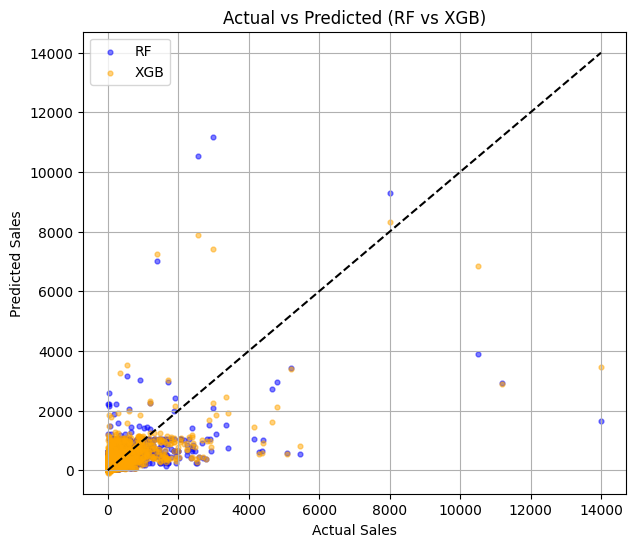

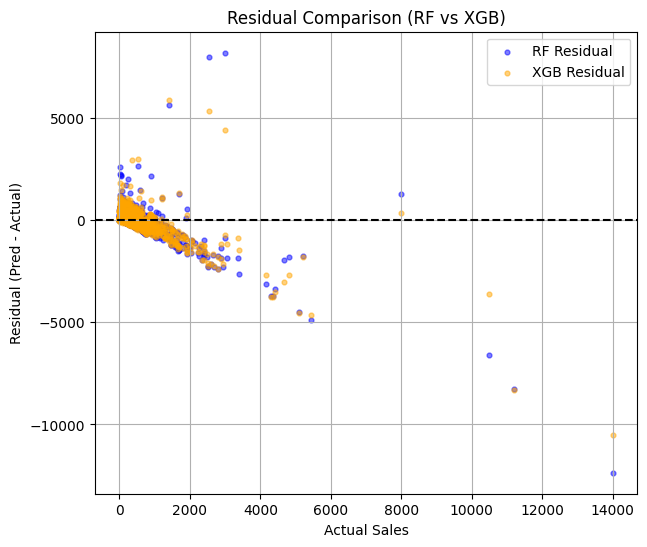

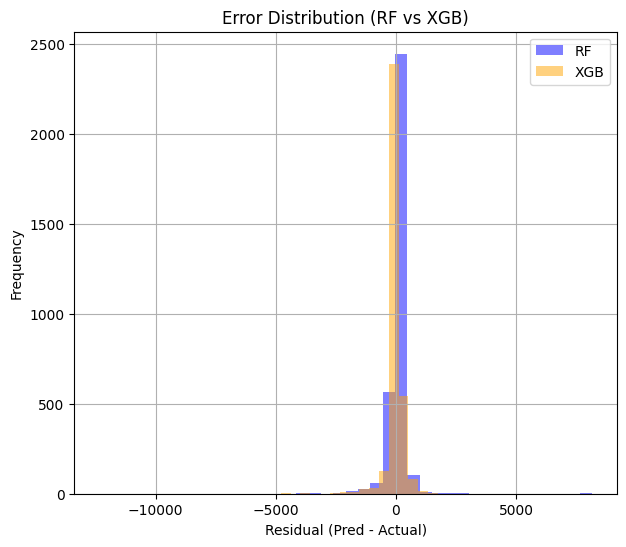

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Dữ liệu
y_true = y_test
rf_pred = rf_final.predict(X_test)
xgb_pred = xgb_final.predict(X_test)

rf_residual = rf_pred - y_true
xgb_residual = xgb_pred - y_true

# ====== 1) Actual vs Predicted (Combined Plot) ======
plt.figure(figsize=(7,6))
plt.scatter(y_true, rf_pred, s=12, alpha=0.5, label="RF", color='blue')
plt.scatter(y_true, xgb_pred, s=12, alpha=0.5, label="XGB", color='orange')

# Đường y = x để tham chiếu
min_y, max_y = y_true.min(), y_true.max()
plt.plot([min_y, max_y], [min_y, max_y], 'k--')

plt.title("Actual vs Predicted (RF vs XGB)")
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.legend()
plt.grid(True)
plt.show()


# ====== 2) Residual Comparison (Combined Plot) ======
plt.figure(figsize=(7,6))
plt.scatter(y_true, rf_residual, s=12, alpha=0.5, label="RF Residual", color='blue')
plt.scatter(y_true, xgb_residual, s=12, alpha=0.5, label="XGB Residual", color='orange')

plt.axhline(0, color='black', linestyle='--')
plt.title("Residual Comparison (RF vs XGB)")
plt.xlabel("Actual Sales")
plt.ylabel("Residual (Pred - Actual)")
plt.legend()
plt.grid(True)
plt.show()


# ====== 3) Error Distribution Overlay (Histogram Combined) ======
plt.figure(figsize=(7,6))

plt.hist(rf_residual, bins=40, alpha=0.5, label="RF", color='blue')
plt.hist(xgb_residual, bins=40, alpha=0.5, label="XGB", color='orange')

plt.title("Error Distribution (RF vs XGB)")
plt.xlabel("Residual (Pred - Actual)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()


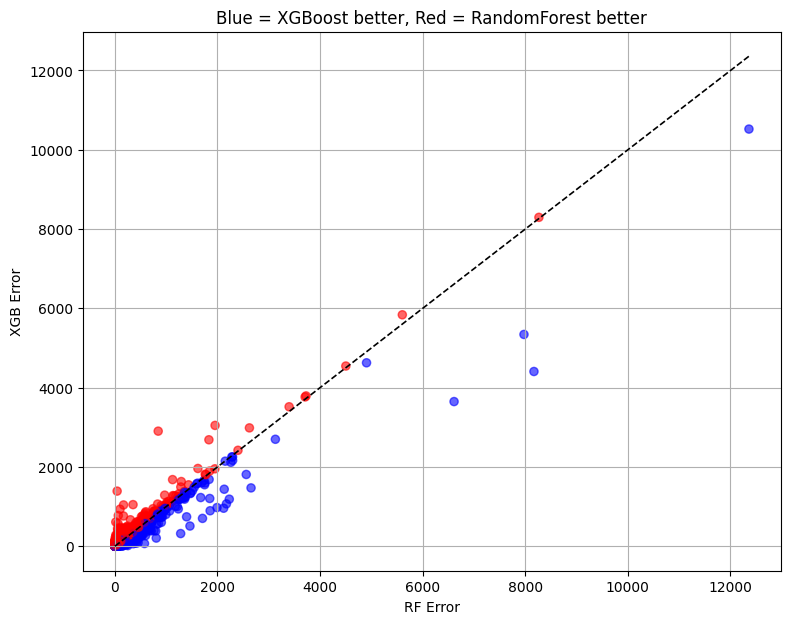

In [ ]:
cmp = pd.DataFrame({
    "rf_err": rf_err,
    "xgb_err": xgb_err
})

# XGB tốt hơn khi xgb_err < rf_err
cmp["winner"] = np.where(cmp["xgb_err"] < cmp["rf_err"], "XGB", "RF")
import matplotlib.pyplot as plt

colors = cmp["winner"].map({"XGB": "blue", "RF": "red"})

plt.figure(figsize=(9,7))
plt.scatter(cmp["rf_err"], cmp["xgb_err"], c=colors, alpha=0.6, s=35)

limit = max(cmp["rf_err"].max(), cmp["xgb_err"].max())
plt.plot([0, limit], [0, limit], "k--", linewidth=1.2)

plt.xlabel("RF Error")
plt.ylabel("XGB Error")
plt.title("Blue = XGBoost better, Red = RandomForest better")
plt.grid(True)
plt.show()
